In [1]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log('dataset\\normal_run_data\\normal_run_data.txt')
df["Attack"] = "R"
print(df)

           Timestamp    ID Flags  DLC                     Data Attack
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2      R
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00      R
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00      R
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00      R
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00      R
...              ...   ...   ...  ...                      ...    ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f      R
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a      R
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00      R
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c      R
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00      R

[988871 rows x 6 columns]


In [2]:
def parse_can_csv(file_path):
    df_can = pd.read_csv(file_path, skipinitialspace=True)

    if 'ID dlc' in df_can.columns:
        df_can[['ID', 'DLC']] = df_can['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_can = df_can.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_can.columns):
        df_can = df_can.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_can = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    unnamed = [c for c in df_can.columns if isinstance(c, str) and c.startswith('Unnamed')]
    if 'Attack' not in df_can.columns and unnamed:
        df_can = df_can.rename(columns={unnamed[-1]: 'Attack'})

    data_cols = sorted(
        [c for c in df_can.columns if isinstance(c, str) and c.lower().startswith('data')],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    def build_data(row):
        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        values = []
        for col in data_cols[:min(dlc, len(data_cols))]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            values.append(s)

        return ' '.join(values).strip()

    def infer_attack(row):
        attack = row.get('Attack')
        if isinstance(attack, str) and attack.strip():
            return attack

        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        for col in data_cols[min(dlc, len(data_cols)):]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            if not re.fullmatch(r'[0-9A-Fa-f]{2}', s):
                return s

        return pd.NA

    if data_cols:
        df_can['Data'] = df_can.apply(build_data, axis=1)
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA
        df_can['Attack'] = df_can.apply(infer_attack, axis=1).combine_first(df_can['Attack'])
    else:
        df_can['Data'] = df_can.get('Data', '').astype(str).str.strip()
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA

    df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce')
    df_can['DLC'] = pd.to_numeric(df_can['DLC'], errors='coerce').astype('Int64')

    return df_can[['Timestamp','ID','DLC','Data','Attack']]

In [3]:
import numpy as np

def sliding_windows_id_data(df, window_size=32, step=2, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    n = len(df)
    num_windows = (n - window_size) // step + 1
    windows = []
    window_labels = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        window_labels.append(attack_label if 'T' in attack[start:end] else 'R')

    return windows, np.array(window_labels, dtype=object)


In [4]:
windowed_id_data0, window_attack_labels0 = sliding_windows_id_data(df, attack_label='D')


In [5]:
df_DoS = parse_can_csv(r'dataset\DoS_dataset.csv')
print(df_DoS.head())
windowed_id_data1, window_attack_labels1 = sliding_windows_id_data(df_DoS, attack_label='D')

del df_DoS

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [6]:
df_Fuzzy = parse_can_csv(r'dataset\Fuzzy_dataset.csv')
print(df_Fuzzy.head())
windowed_id_data2, window_attack_labels2 = sliding_windows_id_data(df_Fuzzy, attack_label='F')

del df_Fuzzy

      Timestamp    ID  DLC                     Data Attack
0  1.478196e+09  0545    8  d8 00 00 8a 00 00 00 00      R
1  1.478196e+09  02b0    5           ff 7f 00 05 49      R
2  1.478196e+09  0002    8  00 00 00 00 00 01 07 15      R
3  1.478196e+09  0153    8  00 21 10 ff 00 ff 00 00      R
4  1.478196e+09  0130    8  19 80 00 ff fe 7f 07 60      R


In [7]:
df_gear = parse_can_csv(r'dataset\gear_dataset.csv')
print(df_gear.head())
windowed_id_data3, window_attack_labels3 = sliding_windows_id_data(df_gear, attack_label='S')

del df_gear

      Timestamp    ID  DLC                     Data Attack
0  1.478193e+09  0140    8  00 00 00 00 10 29 2a 24      R
1  1.478193e+09  02c0    8  15 00 00 00 00 00 00 00      R
2  1.478193e+09  0350    8  05 20 44 68 77 00 00 7e      R
3  1.478193e+09  0370    8  00 20 00 00 00 00 00 00      R
4  1.478193e+09  043f    8  10 40 60 ff 78 c4 08 00      R


In [8]:
df_RPM = parse_can_csv(r'dataset\RPM_dataset.csv')
print(df_RPM.head())
windowed_id_data4, window_attack_labels4 = sliding_windows_id_data(df_RPM, attack_label='S')

del df_RPM

      Timestamp    ID  DLC                     Data Attack
0  1.478191e+09  0316    8  05 22 68 09 22 20 00 75      R
1  1.478191e+09  018f    8  fe 3b 00 00 00 3c 00 00      R
2  1.478191e+09  0260    8  19 22 22 30 ff 8f 6e 3f      R
3  1.478191e+09  02a0    8  60 00 83 1d 96 02 bd 00      R
4  1.478191e+09  0329    8  dc b8 7e 14 11 20 00 14      R


In [9]:
# merge windowed datasets into the single variables used by downstream cells
windowed_id_data = []
windowed_id_data.extend(windowed_id_data0)
windowed_id_data.extend(windowed_id_data1)
windowed_id_data.extend(windowed_id_data2)
windowed_id_data.extend(windowed_id_data3)
windowed_id_data.extend(windowed_id_data4)

window_attack_labels = np.concatenate([
    window_attack_labels0,
    window_attack_labels1,
    window_attack_labels2,
    window_attack_labels3,
    window_attack_labels4
])

print("merged windows:", len(windowed_id_data), "merged labels:", window_attack_labels.shape)

merged windows: 8779097 merged labels: (8779097,)


In [10]:
print(len(windowed_id_data), windowed_id_data[:10])

8779097 [array([['0350', '05 28 84 66 6d 00 00 a2'],
       ['02c0', '14 00 00 00 00 00 00 00'],
       ['0430', '00 00 00 00 00 00 00 00'],
       ['04b1', '00 00 00 00 00 00 00 00'],
       ['01f1', '00 00 00 00 00 00 00 00'],
       ['0153', '00 00 00 ff 00 ff 00 00'],
       ['0002', '00 00 00 00 00 00 00 0a'],
       ['018f', 'fe 36 00 00 00 3c 00 00'],
       ['0130', '03 80 00 ff 21 80 00 9d'],
       ['0131', '00 80 00 00 2d 7f 00 97'],
       ['0140', '00 00 00 00 14 20 20 e6'],
       ['0260', '1b 24 24 30 ff 90 6e 39'],
       ['02a0', '60 00 6b 1d 01 04 dd 00'],
       ['0316', '05 24 84 09 24 23 00 7d'],
       ['0329', '87 b9 7e 14 12 20 00 14'],
       ['0545', 'd8 00 00 8a 00 00 00 00'],
       ['02b0', '8d ff 00 07 02'],
       ['043f', '00 40 60 ff 5a 6c 08 00'],
       ['0370', '00 20 00 00 00 00 00 00'],
       ['0440', 'ff 00 00 00 ff 6c 08 00'],
       ['02c0', '14 00 00 00 00 00 00 00'],
       ['0350', '05 28 94 66 6d 00 00 b2'],
       ['04f0', '00 00 00 80 00 

In [11]:
def _hex_byte_list_from_row(row):
    msg_id, data = row
    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id
    id_bytes = [msg_id[i:i+2] for i in range(0, len(msg_id), 2)]
    data_bytes = [b for b in str(data).split() if b]
    return [int(b, 16) for b in id_bytes + data_bytes]

def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        rows = [_hex_byte_list_from_row(row) for row in window]
        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(np.array(padded_rows, dtype=np.uint8))
    return int_windows

int_windowed_id_data = convert_windowed_id_data_to_ints(windowed_id_data)

print(int_windowed_id_data[0].shape)
print(int_windowed_id_data[0][:2])

(32, 10)
[[  3  80   5  40 132 102 109   0   0 162]
 [  2 192  20   0   0   0   0   0   0   0]]


In [12]:
int_windowed_id_data

[array([[  3,  80,   5,  40, 132, 102, 109,   0,   0, 162],
        [  2, 192,  20,   0,   0,   0,   0,   0,   0,   0],
        [  4,  48,   0,   0,   0,   0,   0,   0,   0,   0],
        [  4, 177,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1, 241,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1,  83,   0,   0,   0, 255,   0, 255,   0,   0],
        [  0,   2,   0,   0,   0,   0,   0,   0,   0,  10],
        [  1, 143, 254,  54,   0,   0,   0,  60,   0,   0],
        [  1,  48,   3, 128,   0, 255,  33, 128,   0, 157],
        [  1,  49,   0, 128,   0,   0,  45, 127,   0, 151],
        [  1,  64,   0,   0,   0,   0,  20,  32,  32, 230],
        [  2,  96,  27,  36,  36,  48, 255, 144, 110,  57],
        [  2, 160,  96,   0, 107,  29,   1,   4, 221,   0],
        [  3,  22,   5,  36, 132,   9,  36,  35,   0, 125],
        [  3,  41, 135, 185, 126,  20,  18,  32,   0,  20],
        [  5,  69, 216,   0,   0, 138,   0,   0,   0,   0],
        [  2, 176, 141, 255,   0,   7,  

In [13]:
window_attack_onehot = np.zeros((len(window_attack_labels), 4), dtype=np.uint8)
window_attack_onehot[window_attack_labels == 'R', 0] = 1
window_attack_onehot[window_attack_labels == 'D', 1] = 1
window_attack_onehot[window_attack_labels == 'F', 2] = 1
window_attack_onehot[window_attack_labels == 'S', 3] = 1

print(window_attack_onehot[:10])

[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [14]:
len(int_windowed_id_data)

8779097

In [15]:
len(window_attack_onehot)

8779097

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

# prepare arrays
X = np.stack(int_windowed_id_data)  # shape (N, 80)
y = window_attack_onehot

# attempt stratified split, fallback if stratify not possible
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=False)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (7023277, 32, 10) X_test: (1755820, 32, 10) y_train: (7023277, 4) y_test: (1755820, 4)


In [ ]:
import tensorflow as tf
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 10, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.LSTM(64, activation='tanh', return_sequences=True))
model.add(layers.Dense(4, activation='softmax'))


ValueError: Input 0 with name 'None' of layer 'lstm_2' is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 64)

: 

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(X_train, y_train, epochs=5, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 195s 69ms/step - accuracy: 0.9947 - loss: 0.0571 - val_accuracy: 0.9988 - val_loss: 0.0065
Epoch 2/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 194s 69ms/step - accuracy: 0.9992 - loss: 0.0042 - val_accuracy: 0.9993 - val_loss: 0.0036
Epoch 3/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 192s 68ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 4/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 196s 70ms/step - accuracy: 0.9996 - loss: 0.0024 - val_accuracy: 0.9996 - val_loss: 0.0029
Epoch 5/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 195s 69ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9996 - val_loss: 0.0020


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0019
Test accuracy: 0.9996


In [ ]:
label_map = np.array(['R', 'D', 'F', 'S'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(X_test))
print(recovered_labels[:20])

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step
['R' 'R' 'R' 'D' 'R' 'D' 'R' 'S' 'R' 'R' 'R' 'F' 'S' 'F' 'R' 'R' 'S' 'S'
 'R' 'R']


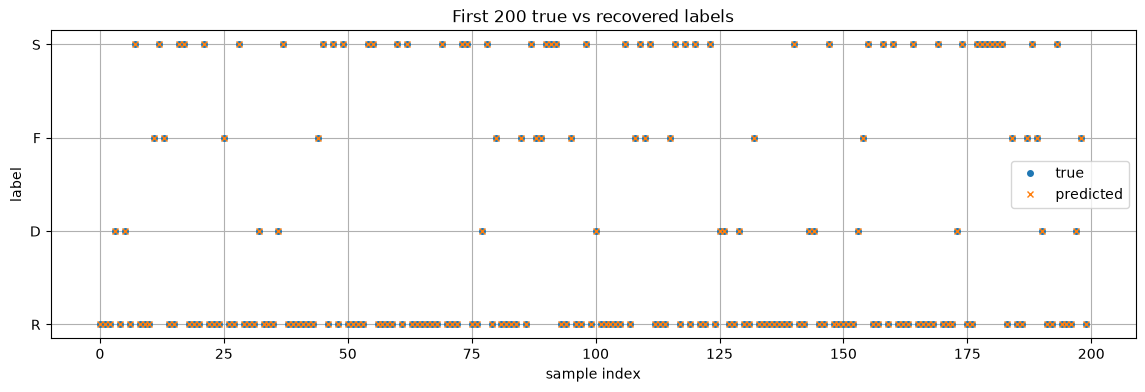

In [ ]:
true_labels = onehot_to_labels(y_test)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(X_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(y_test)

report = classification_report(
    y_true,
    y_pred,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred, labels=label_map)

tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(fps, fps + tns, out=np.zeros_like(fps, dtype=float), where=(fps + tns) != 0)
fnr = np.divide(fns, fns + tps, out=np.zeros_like(fns, dtype=float), where=(fns + tps) != 0)

print("Classification report:")
print(report)
print("Confusion matrix:")
print(cm)

precision = precision_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision, recall, f1, fpr, fnr):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 80s 1ms/step
Classification report:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00   1121598
           D       1.00      1.00      1.00    108678
           F       1.00      1.00      1.00    129093
           S       1.00      1.00      1.00    396451

    accuracy                           1.00   1755820
   macro avg       1.00      1.00      1.00   1755820
weighted avg       1.00      1.00      1.00   1755820

Confusion matrix:
[[1121532      28      29       9]
 [    126  108552       0       0]
 [    147       2  128944       0]
 [    292       0       2  396157]]
R: precision=0.9995, recall=0.9999, f1=0.9997, false positive rate=0.0009, false negative rate=0.0001
D: precision=0.9997, recall=0.9988, f1=0.9993, false positive rate=0.0000, false negative rate=0.0012
F: precision=0.9998, recall=0.9988, f1=0.9993, false positive rate=0.0000, false negative rate=0.0012
S: precision=1.0000, recall=0.9

In [ ]:
import json

# Save model architecture to JSON
model_json = model.to_json()
with open('model_architecture.json', 'w') as json_file:
    json_file.write(model_json)

# Save model weights separately
model.save_weights('model_weights.weights.h5')

print("Model architecture saved to 'model_architecture.json'")
print("Model weights saved to 'model_weights.weights.h5'")

Model architecture saved to 'model_architecture.json'
Model weights saved to 'model_weights.weights.h5'


: 